# Q5 model comparison

This notebook compares four one-year-ahead forecasting methods for the
survey-weighted frequent volunteering rate:

- Naive baseline;
- Ridge Regression;
- Random Forest;
- Gradient Boosting.

The modelling unit is one `year × borough × age group × activity level` cell.
The target is `frequent_volunteer_rate`.

The annual split:

- Years 3–6: model fitting and hyperparameter development;
- Year 7: hyperparameter and forecasting-method selection;
- Year 8: untouched independent test.

> **Interpretation boundary.** 
> The target is a survey-weighted cell estimate rather than an individual-level outcome. Many cells have small effective sample sizes, so overall predictive performance must be interpreted alongside subgroup and reliability diagnostics.

## 1 — Load and validate the complete panel

Define the input panel, output locations, target, annual split and reproducibility settings.

Reliability variables such as effective sample size and small-cell status are retained for evaluation and sensitivity analysis. They are not used as behavioural predictors.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

pd.set_option(
    "display.max_columns",
    80,
)

PROJECT_DIR = Path(
    "/Users/zsh/Downloads/PROJECT/code"
)

PANEL_PATH = (
    PROJECT_DIR
    / "q5_versionA_borough_age_activitylevel_panel_complete.csv"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "q5_model_comparison_outputs"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET = "frequent_volunteer_rate"
LAG_FEATURE = "frequent_volunteer_rate_lag1"

TRAIN_YEARS = [3, 4, 5, 6]
VALIDATION_YEAR = 7
TEST_YEAR = 8

COVID_OVERLAP_YEARS = [5, 6, 7]

RANDOM_STATE = 2026

MODEL_NAMES = [
    "Naive baseline",
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]

MODEL_COMPLEXITY_ORDER = {
    "Naive baseline": 0,
    "Ridge Regression": 1,
    "Random Forest": 2,
    "Gradient Boosting": 3,
}

In [2]:
def parse_nullable_boolean(series):
    text_values = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return text_values.map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    ).astype("boolean")


if not PANEL_PATH.exists():
    raise FileNotFoundError(
        f"File not found: {PANEL_PATH}"
    )

q5_panel = pd.read_csv(
    PANEL_PATH,
    low_memory=False,
)

required_columns = [
    "series_id",
    "year",
    "LA_2023",
    "age_group_code",
    "age_group",
    "activity_level_3cat",
    "activity_level_3cat_label",
    TARGET,
    "effective_n_parent_cell",
    "small_cell",
]

missing_columns = [
    column
    for column in required_columns
    if column not in q5_panel.columns
]

if missing_columns:
    raise ValueError(
        f"Missing panel columns: "
        f"{missing_columns}"
    )

numeric_columns = [
    "year",
    "LA_2023",
    "age_group_code",
    "activity_level_3cat",
    TARGET,
    "effective_n_parent_cell",
]

for column in numeric_columns:
    q5_panel[column] = pd.to_numeric(
        q5_panel[column],
        errors="coerce",
    )

q5_panel["small_cell"] = (
    parse_nullable_boolean(
        q5_panel["small_cell"]
    )
)

if sorted(
    q5_panel["year"]
    .dropna()
    .astype(int)
    .unique()
) != [3, 4, 5, 6, 7, 8]:
    raise ValueError(
        "Unexpected historical years"
    )

if q5_panel.duplicated(
    subset=[
        "series_id",
        "year",
    ]
).any():
    raise ValueError(
        "Duplicate series-year rows found"
    )

series_lengths = (
    q5_panel
    .groupby("series_id")
    .size()
)

if not series_lengths.eq(6).all():
    raise ValueError(
        "Every series must contain exactly six annual rows"
    )

observed_target = q5_panel[
    TARGET
].notna()

if not q5_panel.loc[
    observed_target,
    TARGET,
].between(0, 1).all():
    raise ValueError(
        "An observed target falls outside the interval [0, 1]"
    )

if q5_panel[
    [
        "age_group",
        "activity_level_3cat_label",
    ]
].isna().any().any():
    raise ValueError(
        "The complete panel contains missing age or activity labels"
    )

print(
    f"Loaded complete panel: "
    f"{q5_panel.shape[0]:,} rows, "
    f"{q5_panel.shape[1]} columns"
)

print(
    f"Observed targets: "
    f"{q5_panel[TARGET].notna().sum():,}"
)

Loaded complete panel: 4,608 rows, 26 columns
Observed targets: 4,127


## 2 — Create the fixed Q5 feature set

The primary predictors are fixed before hyperparameter tuning:

- the same series' previous-year volunteering rate;
- an indicator showing whether the previous-year rate is unavailable;
- a linear time trend;
- borough identity;
- a combined age–activity category.

The combined age–activity category represents all 24 age-by-activity groups. It allows the predicted difference between activity levels to vary across age groups.

In [3]:
q5_model_panel = (
    q5_panel
    .sort_values(
        [
            "series_id",
            "year",
        ]
    )
    .reset_index(drop=True)
)

q5_model_panel[
    LAG_FEATURE
] = (
    q5_model_panel
    .groupby(
        "series_id",
        sort=False,
    )[TARGET]
    .shift(1)
)

q5_model_panel[
    "lag_1_available"
] = q5_model_panel[
    LAG_FEATURE
].notna()

q5_model_panel[
    "lag_1_missing"
] = (
    ~q5_model_panel[
        "lag_1_available"
    ]
).astype(int)

q5_model_panel[
    "time_trend"
] = (
    q5_model_panel["year"]
    - min(TRAIN_YEARS)
)

q5_model_panel[
    "borough_category"
] = (
    q5_model_panel[
        "LA_2023"
    ]
    .astype("Int64")
    .astype("string")
)

q5_model_panel[
    "age_activity_group"
] = (
    q5_model_panel[
        "age_group"
    ].astype("string")
    + "__"
    + q5_model_panel[
        "activity_level_3cat_label"
    ].astype("string")
)

q5_model_panel[
    "covid_overlap"
] = (
    q5_model_panel["year"]
    .isin(
        COVID_OVERLAP_YEARS
    )
    .astype(int)
)

q5_model_panel[
    "target_available"
] = q5_model_panel[
    TARGET
].notna()

q5_model_panel[
    "sqrt_effective_n"
] = np.sqrt(
    q5_model_panel[
        "effective_n_parent_cell"
    ]
)

NUMERIC_FEATURES = [
    LAG_FEATURE,
    "lag_1_missing",
    "time_trend",
]

CATEGORICAL_FEATURES = [
    "borough_category",
    "age_activity_group",
]

print("Numeric features:")
print(NUMERIC_FEATURES)

print("\nCategorical features:")
print(CATEGORICAL_FEATURES)

print(
    f"\nObserved targets: "
    f"{q5_model_panel['target_available'].sum():,}"
)

print(
    f"Observed targets with an available lag: "
    f"{q5_model_panel.loc[q5_model_panel['target_available'], 'lag_1_available'].sum():,}"
)

print(
    f"Age-activity categories: "
    f"{q5_model_panel['age_activity_group'].nunique()}"
)

Numeric features:
['frequent_volunteer_rate_lag1', 'lag_1_missing', 'time_trend']

Categorical features:
['borough_category', 'age_activity_group']

Observed targets: 4,127
Observed targets with an available lag: 3,260
Age-activity categories: 24


## 3 — Define the annual development and test samples

- Years 3–6 train every hyperparameter candidate;
- Year 7 selects each model's hyperparameters and then the forecasting
  method;
- Year 8 remains untouched until all development choices are frozen.

This is a single annual validation holdout rather than multi-fold cross-validation. Parameter and model selection may therefore be sensitive to the specific Year 7 outcome, and no fold-to-fold standard deviation can be estimated.

The primary four-model comparison uses only rows where the one-year lag is available because the naive baseline cannot predict without it. Machine-learning performance on all observed targets is also reported as a coverage diagnostic.

In [4]:
development_train = q5_model_panel.loc[
    q5_model_panel[
        "target_available"
    ]
    & q5_model_panel[
        "year"
    ].isin(TRAIN_YEARS)
].copy()

validation = q5_model_panel.loc[
    q5_model_panel[
        "target_available"
    ]
    & q5_model_panel[
        "year"
    ].eq(VALIDATION_YEAR)
].copy()

validation_common = validation.loc[
    validation[
        "lag_1_available"
    ]
].copy()

test = q5_model_panel.loc[
    q5_model_panel[
        "target_available"
    ]
    & q5_model_panel[
        "year"
    ].eq(TEST_YEAR)
].copy()

test_common = test.loc[
    test[
        "lag_1_available"
    ]
].copy()

if development_train.empty:
    raise ValueError(
        "The development training sample is empty"
    )

if validation.empty:
    raise ValueError(
        "The Year 7 validation sample is empty"
    )

if validation_common.empty:
    raise ValueError(
        "The Year 7 common comparison sample is empty"
    )

if test.empty:
    raise ValueError(
        "The Year 8 test sample is empty"
    )

if test_common.empty:
    raise ValueError(
        "The Year 8 common comparison sample is empty"
    )

split_overview = pd.DataFrame(
    {
        "sample": [
            "Development training",
            "Year 7 validation",
            "Year 7 common comparison",
            "Year 8 test",
            "Year 8 common comparison",
        ],
        "years": [
            "3-6",
            "7",
            "7",
            "8",
            "8",
        ],
        "rows": [
            len(development_train),
            len(validation),
            len(validation_common),
            len(test),
            len(test_common),
        ],
    }
)

display(split_overview)

,sample,years,rows
0,Development training,3-6,2698
1,Year 7 validation,7,713
2,Year 7 common comparison,7,681
3,Year 8 test,8,716
4,Year 8 common comparison,8,685


## 4 — Inspect the Q5 development data

The hyperparameter candidates are defined using only the Q5 development sample.

This diagnostic summarises the number of training observations, target distribution, lag availability and effective sample size. These properties inform the level of regularisation and smoothing included in the candidate grid.

In [5]:
development_diagnostics = pd.DataFrame(
    {
        "measure": [
            "Training rows",
            "Training series",
            "Target mean",
            "Target median",
            "Zero-target proportion",
            "Lag-missing proportion",
            "Median effective sample size",
            "Effective n below 5",
            "Effective n below 10",
        ],
        "value": [
            len(development_train),
            development_train[
                "series_id"
            ].nunique(),
            development_train[
                TARGET
            ].mean(),
            development_train[
                TARGET
            ].median(),
            development_train[
                TARGET
            ].eq(0).mean(),
            development_train[
                "lag_1_missing"
            ].mean(),
            development_train[
                "effective_n_parent_cell"
            ].median(),
            development_train[
                "effective_n_parent_cell"
            ].lt(5).mean(),
            development_train[
                "effective_n_parent_cell"
            ].lt(10).mean(),
        ],
    }
)

display(
    development_diagnostics
)

target_quantiles = (
    development_train[
        TARGET
    ]
    .quantile(
        [
            0.00,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            1.00,
        ]
    )
    .rename_axis(
        "quantile"
    )
    .reset_index(
        name="target_value"
    )
)

display(
    target_quantiles
)

,measure,value
0,Training rows,2698.000000
1,Training series,746.000000
2,Target mean,0.086619
3,Target median,0.000000
4,Zero-target proportion,0.521127
5,Lag-missing proportion,0.297999
6,Median effective sample size,4.863763
7,Effective n below 5,0.512602
8,Effective n below 10,0.732765


,quantile,target_value
0,0.00,0.000000
1,0.25,0.000000
2,0.50,0.000000
3,0.75,0.123192
4,0.90,0.245171
5,0.95,0.374083
6,1.00,1.000000


## 5 — Metrics, parameter candidates and model pipelines

Mean absolute error on the common Year 7 sample is the primary selection metric.

Unweighted MAE is the primary selection metric because the research question requires predictions for every borough–age–activity level cell, so each cell is given equal importance in the main comparison.

Effective-sample-weighted metrics are reported separately to assess performance among more reliable survey cells.

For the two-category outcome `(frequent, not frequent)`, total variation is equal to the absolute error in the predicted frequent volunteering rate. MAE is therefore the direct Q5 counterpart of the Q1 annual total-variation criterion.

RMSE, R², mean error and effective-sample-weighted errors are retained as secondary diagnostics. The primary ranking remains unweighted to match the current Q1 annual comparison.

Each machine-learning method evaluates four pre-specified hyperparameter configurations. This keeps the tuning budget aligned with the Q1 annual comparison.

The candidate values are tailored to the Q5 development data. The Q5 panel contains noisy survey-weighted cell estimates, many small effective sample sizes and a relatively compact predictor set. Therefore, the candidate grid emphasises regularisation, shallow trees and sufficiently large terminal nodes.

The parameter ranges are fixed before evaluating Year 7. The Year 8 test sample cannot be used to revise them.

Predictions are clipped to the valid interval `[0, 1]`, and the clipping rate is reported.

In [6]:
def parameter_candidates(model_name):
    if model_name == "Ridge Regression":
        return [
            {
                "alpha": 1.0,
            },
            {
                "alpha": 10.0,
            },
            {
                "alpha": 100.0,
            },
            {
                "alpha": 1000.0,
            },
        ]

    if model_name == "Random Forest":
        return [
            {
                "n_estimators": 300,
                "max_depth": 4,
                "min_samples_leaf": 40,
                "max_features": 0.5,
            },
            {
                "n_estimators": 300,
                "max_depth": 6,
                "min_samples_leaf": 20,
                "max_features": 0.5,
            },
            {
                "n_estimators": 400,
                "max_depth": 8,
                "min_samples_leaf": 10,
                "max_features": 0.7,
            },
            {
                "n_estimators": 400,
                "max_depth": None,
                "min_samples_leaf": 30,
                "max_features": 0.3,
            },
        ]

    if model_name == "Gradient Boosting":
        return [
            {
                "n_estimators": 150,
                "learning_rate": 0.03,
                "max_depth": 1,
                "min_samples_leaf": 30,
            },
            {
                "n_estimators": 200,
                "learning_rate": 0.03,
                "max_depth": 2,
                "min_samples_leaf": 30,
            },
            {
                "n_estimators": 150,
                "learning_rate": 0.05,
                "max_depth": 2,
                "min_samples_leaf": 20,
            },
            {
                "n_estimators": 300,
                "learning_rate": 0.02,
                "max_depth": 2,
                "min_samples_leaf": 40,
            },
        ]

    raise ValueError(
        f"Unknown model: {model_name}"
    )


def build_model(
    model_name,
    parameters,
    numeric_features,
    categorical_features,
):
    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        )
    ]

    if model_name == "Ridge Regression":
        numeric_steps.append(
            (
                "scale",
                StandardScaler(),
            )
        )

    categorical_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]

    preprocessing = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    numeric_steps
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    categorical_steps
                ),
                categorical_features,
            ),
        ]
    )

    if model_name == "Ridge Regression":
        estimator = Ridge(
            **parameters
        )

    elif model_name == "Random Forest":
        estimator = RandomForestRegressor(
            **parameters,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

    elif model_name == "Gradient Boosting":
        estimator = GradientBoostingRegressor(
            **parameters,
            random_state=RANDOM_STATE,
            loss="huber",
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return Pipeline(
        steps=[
            (
                "preprocess",
                preprocessing,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )


def weighted_average(
    values,
    weights,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not valid.any():
        return np.nan

    return np.average(
        values[valid],
        weights=weights[valid],
    )


def normalise_sample_weight(
    sample_weight,
):
    weights = np.asarray(
        sample_weight,
        dtype=float,
    )

    if not np.isfinite(weights).all():
        raise ValueError(
            "Training weights contain non-finite values"
        )

    if not (weights > 0).all():
        raise ValueError(
            "Training weights must be positive"
        )

    return weights / weights.mean()


def score_predictions(
    actual,
    predicted,
    raw_predicted,
    effective_n,
):
    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    raw_predicted = np.asarray(
        raw_predicted,
        dtype=float,
    )

    effective_n = np.asarray(
        effective_n,
        dtype=float,
    )

    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
        & np.isfinite(raw_predicted)
    )

    actual = actual[valid]
    predicted = predicted[valid]
    raw_predicted = raw_predicted[valid]
    effective_n = effective_n[valid]

    if len(actual) == 0:
        raise ValueError(
            "No valid observations were available for evaluation"
        )

    absolute_error = np.abs(
        actual - predicted
    )

    squared_error = (
        actual - predicted
    ) ** 2

    clipped = (
        (raw_predicted < 0)
        | (raw_predicted > 1)
    )

    if (
        len(actual) < 2
        or np.isclose(
            np.var(actual),
            0,
        )
    ):
        r2 = np.nan
    else:
        r2 = r2_score(
            actual,
            predicted,
        )

    weighted_mse = weighted_average(
        squared_error,
        effective_n,
    )

    return {
        "observations": len(actual),
        "mae": mean_absolute_error(
            actual,
            predicted,
        ),
        "rmse": np.sqrt(
            mean_squared_error(
                actual,
                predicted,
            )
        ),
        "r2": r2,
        "mean_error": np.mean(
            predicted - actual
        ),
        "effective_n_weighted_mae": (
            weighted_average(
                absolute_error,
                effective_n,
            )
        ),
        "effective_n_weighted_rmse": (
            np.sqrt(weighted_mse)
            if pd.notna(weighted_mse)
            else np.nan
        ),
        "clipped_predictions": int(
            clipped.sum()
        ),
        "clip_rate": clipped.mean(),
    }


def fit_model(
    model,
    train,
    feature_columns,
    sample_weight=None,
):
    fit_arguments = {}

    if sample_weight is not None:
        fit_arguments[
            "model__sample_weight"
        ] = normalise_sample_weight(
            sample_weight
        )

    model.fit(
        train[feature_columns],
        train[TARGET],
        **fit_arguments,
    )

    return model


def predict_rate(
    model,
    data,
    feature_columns,
):
    raw_prediction = np.asarray(
        model.predict(
            data[feature_columns]
        ),
        dtype=float,
    ).reshape(-1)

    prediction = np.clip(
        raw_prediction,
        0,
        1,
    )

    return (
        prediction,
        raw_prediction,
    )

## 6 — Evaluation helpers

Every machine-learning candidate is fitted on all available target rows from the training years.

Median imputation handles missing lag values inside the training pipeline, while `lag_1_missing` explicitly records whether the lag was unavailable.

Primary validation metrics use the common lag-available sample. A second all-target metric is retained for the machine-learning models to describe their wider prediction coverage.

In [7]:
PREDICTION_COLUMNS = [
    "series_id",
    "year",
    "LA_2023",
    "age_group_code",
    "age_group",
    "activity_level_3cat",
    "activity_level_3cat_label",
    TARGET,
    LAG_FEATURE,
    "lag_1_available",
    "effective_n_parent_cell",
    "small_cell",
    "covid_overlap",
]


def make_prediction_table(
    data,
    model_name,
    phase,
    predicted,
    raw_predicted,
):
    output = data[
        PREDICTION_COLUMNS
    ].copy()

    output["model"] = model_name
    output["phase"] = phase

    output[
        "predicted_frequent_volunteer_rate"
    ] = predicted

    output[
        "raw_predicted_frequent_volunteer_rate"
    ] = raw_predicted

    output[
        "absolute_error"
    ] = np.abs(
        output[TARGET]
        - output[
            "predicted_frequent_volunteer_rate"
        ]
    )

    return output


def evaluate_prediction_table(
    prediction_table,
    evaluation_sample,
):
    if prediction_table.empty:
        raise ValueError(
            "The prediction table is empty"
        )

    if evaluation_sample == "common_lag_available":
        evaluation = prediction_table.loc[
            prediction_table[
                "lag_1_available"
            ]
        ].copy()

    elif evaluation_sample == "all_target_rows":
        evaluation = prediction_table.copy()

    else:
        raise ValueError(
            f"Unknown evaluation sample: "
            f"{evaluation_sample}"
        )

    metrics = score_predictions(
        actual=evaluation[TARGET],
        predicted=evaluation[
            "predicted_frequent_volunteer_rate"
        ],
        raw_predicted=evaluation[
            "raw_predicted_frequent_volunteer_rate"
        ],
        effective_n=evaluation[
            "effective_n_parent_cell"
        ],
    )

    return {
        "model": prediction_table[
            "model"
        ].iloc[0],
        "phase": prediction_table[
            "phase"
        ].iloc[0],
        "evaluation_sample": (
            evaluation_sample
        ),
        **metrics,
    }


def evaluate_machine_learning_model(
    train,
    evaluation,
    model_name,
    parameters,
    phase,
    numeric_features=None,
    categorical_features=None,
    sample_weight_column=None,
):
    if numeric_features is None:
        numeric_features = NUMERIC_FEATURES

    if categorical_features is None:
        categorical_features = (
            CATEGORICAL_FEATURES
        )

    feature_columns = (
        numeric_features
        + categorical_features
    )

    model = build_model(
        model_name=model_name,
        parameters=parameters,
        numeric_features=numeric_features,
        categorical_features=(
            categorical_features
        ),
    )

    sample_weight = None

    if sample_weight_column is not None:
        sample_weight = train[
            sample_weight_column
        ].to_numpy()

    model = fit_model(
        model=model,
        train=train,
        feature_columns=feature_columns,
        sample_weight=sample_weight,
    )

    (
        predicted,
        raw_predicted,
    ) = predict_rate(
        model=model,
        data=evaluation,
        feature_columns=feature_columns,
    )

    prediction_table = make_prediction_table(
        data=evaluation,
        model_name=model_name,
        phase=phase,
        predicted=predicted,
        raw_predicted=raw_predicted,
    )

    return (
        model,
        prediction_table,
    )


def evaluate_naive(
    evaluation,
    phase,
):
    available = evaluation.loc[
        evaluation[
            "lag_1_available"
        ]
    ].copy()

    predicted = available[
        LAG_FEATURE
    ].to_numpy()

    return make_prediction_table(
        data=available,
        model_name="Naive baseline",
        phase=phase,
        predicted=predicted,
        raw_predicted=predicted,
    )

## 7 — Tune each machine-learning model on Year 7

Each machine-learning model evaluates four pre-specified hyperparameter candidates.

The candidate with the lowest Year 7 MAE on the common lag-available sample is selected. RMSE, clipping rate and candidate order are used as pre-defined tie-breakers.

Because only one annual validation year is used, this is a development validation comparison rather than an estimate of average performance across multiple folds.

In [8]:
def tune_model(
    model_name,
):
    tuning_rows = []

    candidates = parameter_candidates(
        model_name
    )

    for candidate_id, parameters in enumerate(
        candidates,
        start=1,
    ):
        _, predictions = (
            evaluate_machine_learning_model(
                train=development_train,
                evaluation=validation,
                model_name=model_name,
                parameters=parameters,
                phase="Year 7 validation",
            )
        )

        common_metrics = (
            evaluate_prediction_table(
                prediction_table=predictions,
                evaluation_sample=(
                    "common_lag_available"
                ),
            )
        )

        all_metrics = (
            evaluate_prediction_table(
                prediction_table=predictions,
                evaluation_sample=(
                    "all_target_rows"
                ),
            )
        )

        tuning_rows.append(
            {
                "model": model_name,
                "candidate_id": candidate_id,
                "parameters": json.dumps(
                    parameters,
                    sort_keys=True,
                ),
                "validation_mae": (
                    common_metrics["mae"]
                ),
                "validation_rmse": (
                    common_metrics["rmse"]
                ),
                "validation_r2": (
                    common_metrics["r2"]
                ),
                "validation_weighted_mae": (
                    common_metrics[
                        "effective_n_weighted_mae"
                    ]
                ),
                "validation_clip_rate": (
                    common_metrics[
                        "clip_rate"
                    ]
                ),
                "all_target_mae": (
                    all_metrics["mae"]
                ),
                "all_target_rows": (
                    all_metrics[
                        "observations"
                    ]
                ),
            }
        )

    tuning_table = (
        pd.DataFrame(
            tuning_rows
        )
        .sort_values(
            [
                "validation_mae",
                "validation_rmse",
                "validation_clip_rate",
                "candidate_id",
            ]
        )
        .reset_index(drop=True)
    )

    best_row = tuning_table.iloc[0]

    best_parameters = json.loads(
        best_row["parameters"]
    )

    return {
        "tuning_table": tuning_table,
        "best_parameters": best_parameters,
    }


tuning_results = {}

for model_name in [
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]:
    tuning_results[
        model_name
    ] = tune_model(
        model_name=model_name
    )

    print(
        f"Best parameters for "
        f"{model_name}:"
    )

    print(
        tuning_results[
            model_name
        ]["best_parameters"]
    )

    display(
        tuning_results[
            model_name
        ]["tuning_table"]
    )

Best parameters for Ridge Regression:
{'alpha': 10.0}


,model,candidate_id,parameters,validation_mae,validation_rmse,validation_r2,validation_weighted_mae,validation_clip_rate,all_target_mae,all_target_rows
0,Ridge Regression,2,"{""alpha"": 10.0}",0.082593,0.120207,0.049491,0.063920,0.005874,0.084342,713
1,Ridge Regression,1,"{""alpha"": 1.0}",0.082703,0.120679,0.042015,0.064187,0.013216,0.084455,713
2,Ridge Regression,3,"{""alpha"": 100.0}",0.084138,0.119749,0.056725,0.065502,0.000000,0.085756,713
3,Ridge Regression,4,"{""alpha"": 1000.0}",0.089171,0.122343,0.015415,0.071861,0.000000,0.090638,713


Best parameters for Random Forest:
{'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 30, 'n_estimators': 400}


,model,candidate_id,parameters,validation_mae,validation_rmse,validation_r2,validation_weighted_mae,validation_clip_rate,all_target_mae,all_target_rows
0,Random Forest,4,"{""max_depth"": null, ""max_features"": 0.3, ""min_...",0.082363,0.119773,0.056350,0.065262,0.0,0.083750,713
1,Random Forest,3,"{""max_depth"": 8, ""max_features"": 0.7, ""min_sam...",0.084539,0.120962,0.037521,0.068343,0.0,0.086186,713
2,Random Forest,2,"{""max_depth"": 6, ""max_features"": 0.5, ""min_sam...",0.085267,0.120570,0.043741,0.068026,0.0,0.086779,713
3,Random Forest,1,"{""max_depth"": 4, ""max_features"": 0.5, ""min_sam...",0.085866,0.120458,0.045527,0.068326,0.0,0.087372,713


Best parameters for Gradient Boosting:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'n_estimators': 150}


,model,candidate_id,parameters,validation_mae,validation_rmse,validation_r2,validation_weighted_mae,validation_clip_rate,all_target_mae,all_target_rows
0,Gradient Boosting,3,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",0.077379,0.122813,0.007839,0.066224,0.0,0.078021,713
1,Gradient Boosting,4,"{""learning_rate"": 0.02, ""max_depth"": 2, ""min_s...",0.077707,0.122790,0.008203,0.065962,0.0,0.078350,713
2,Gradient Boosting,2,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.078155,0.122979,0.005148,0.067108,0.0,0.078836,713
3,Gradient Boosting,1,"{""learning_rate"": 0.03, ""max_depth"": 1, ""min_s...",0.080902,0.123551,-0.004128,0.069570,0.0,0.081684,713


## 8 — Compare the tuned models with the naive baseline

The naive forecast uses the same series' Year 6 volunteering rate. Each machine-learning model uses its own Year 7-selected hyperparameters.

The forecasting method with the lowest common-sample Year 7 MAE is selected. RMSE, clipping rate and pre-defined model complexity are used only when the preceding criteria are tied.

This decision is frozen before the Year 8 test is evaluated.

In [9]:
selected_parameters = {
    model_name: tuning_results[
        model_name
    ]["best_parameters"]
    for model_name in [
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
    ]
}

validation_prediction_tables = []
validation_metric_rows = []

naive_validation_predictions = (
    evaluate_naive(
        evaluation=validation,
        phase="Year 7 validation",
    )
)

validation_prediction_tables.append(
    naive_validation_predictions
)

validation_metric_rows.append(
    evaluate_prediction_table(
        prediction_table=(
            naive_validation_predictions
        ),
        evaluation_sample=(
            "common_lag_available"
        ),
    )
)

for model_name in [
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]:
    _, predictions = (
        evaluate_machine_learning_model(
            train=development_train,
            evaluation=validation,
            model_name=model_name,
            parameters=(
                selected_parameters[
                    model_name
                ]
            ),
            phase="Year 7 validation",
        )
    )

    validation_prediction_tables.append(
        predictions
    )

    validation_metric_rows.append(
        evaluate_prediction_table(
            prediction_table=predictions,
            evaluation_sample=(
                "common_lag_available"
            ),
        )
    )

    validation_metric_rows.append(
        evaluate_prediction_table(
            prediction_table=predictions,
            evaluation_sample=(
                "all_target_rows"
            ),
        )
    )

validation_predictions = pd.concat(
    validation_prediction_tables,
    ignore_index=True,
)

validation_metrics = pd.DataFrame(
    validation_metric_rows
)

common_validation_metrics = (
    validation_metrics.loc[
        validation_metrics[
            "evaluation_sample"
        ].eq(
            "common_lag_available"
        )
    ]
    .copy()
)

common_validation_metrics[
    "complexity_order"
] = common_validation_metrics[
    "model"
].map(
    MODEL_COMPLEXITY_ORDER
)

common_validation_metrics = (
    common_validation_metrics
    .sort_values(
        [
            "mae",
            "rmse",
            "clip_rate",
            "complexity_order",
        ]
    )
    .reset_index(drop=True)
)

selected_model = (
    common_validation_metrics
    .iloc[0]["model"]
)

naive_validation_mae = (
    common_validation_metrics.loc[
        common_validation_metrics[
            "model"
        ].eq(
            "Naive baseline"
        ),
        "mae",
    ]
    .iloc[0]
)

common_validation_metrics[
    "mae_skill_vs_naive"
] = (
    1
    - common_validation_metrics["mae"]
    / naive_validation_mae
)

print(
    f"Year 7-selected model: "
    f"{selected_model}"
)

display(
    common_validation_metrics.drop(
        columns="complexity_order"
    )
)

Year 7-selected model: Gradient Boosting


,model,phase,evaluation_sample,observations,mae,rmse,r2,mean_error,effective_n_weighted_mae,effective_n_weighted_rmse,clipped_predictions,clip_rate,mae_skill_vs_naive
0,Gradient Boosting,Year 7 validation,common_lag_available,681,0.077379,0.122813,0.007839,-0.031746,0.066224,0.094590,0,0.000000,0.210710
1,Random Forest,Year 7 validation,common_lag_available,681,0.082363,0.119773,0.056350,-0.011751,0.065262,0.089856,0,0.000000,0.159867
2,Ridge Regression,Year 7 validation,common_lag_available,681,0.082593,0.120207,0.049491,-0.007632,0.063920,0.088574,4,0.005874,0.157527
3,Naive baseline,Year 7 validation,common_lag_available,681,0.098036,0.171294,-0.930092,-0.017604,0.085574,0.125313,0,0.000000,0.000000


## 9 — Evaluate the independent Year 8 test

The three machine-learning methods are refitted using Years 3–7 and the hyperparameters selected from Year 7. The naive baseline uses the same series' Year 7 rate.

All four methods are evaluated on the common Year 8 lag-available sample. Machine-learning models are also evaluated on all observed Year 8 targets.

The Year 8 results are final evaluation outputs only. They do not replace the model selected from Year 7.

In [10]:
final_train = q5_model_panel.loc[
    q5_model_panel[
        "target_available"
    ]
    & q5_model_panel[
        "year"
    ].lt(TEST_YEAR)
].copy()

test_prediction_tables = []
test_metric_rows = []
fitted_test_models = {}

naive_test_predictions = evaluate_naive(
    evaluation=test,
    phase="Year 8 independent test",
)

test_prediction_tables.append(
    naive_test_predictions
)

test_metric_rows.append(
    evaluate_prediction_table(
        prediction_table=(
            naive_test_predictions
        ),
        evaluation_sample=(
            "common_lag_available"
        ),
    )
)

for model_name in [
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]:
    model, predictions = (
        evaluate_machine_learning_model(
            train=final_train,
            evaluation=test,
            model_name=model_name,
            parameters=(
                selected_parameters[
                    model_name
                ]
            ),
            phase=(
                "Year 8 independent test"
            ),
        )
    )

    fitted_test_models[
        model_name
    ] = model

    test_prediction_tables.append(
        predictions
    )

    test_metric_rows.append(
        evaluate_prediction_table(
            prediction_table=predictions,
            evaluation_sample=(
                "common_lag_available"
            ),
        )
    )

    test_metric_rows.append(
        evaluate_prediction_table(
            prediction_table=predictions,
            evaluation_sample=(
                "all_target_rows"
            ),
        )
    )

test_predictions = pd.concat(
    test_prediction_tables,
    ignore_index=True,
)

test_metrics = pd.DataFrame(
    test_metric_rows
)

common_test_metrics = (
    test_metrics.loc[
        test_metrics[
            "evaluation_sample"
        ].eq(
            "common_lag_available"
        )
    ]
    .copy()
)

naive_test_mae = (
    common_test_metrics.loc[
        common_test_metrics[
            "model"
        ].eq(
            "Naive baseline"
        ),
        "mae",
    ]
    .iloc[0]
)

common_test_metrics[
    "mae_skill_vs_naive"
] = (
    1
    - common_test_metrics["mae"]
    / naive_test_mae
)

common_test_metrics[
    "selected_on_year_7"
] = common_test_metrics[
    "model"
].eq(
    selected_model
)

common_test_metrics = (
    common_test_metrics
    .sort_values(
        "mae"
    )
    .reset_index(drop=True)
)

print(
    f"Frozen development-selected model: "
    f"{selected_model}"
)

display(
    common_test_metrics
)

Frozen development-selected model: Gradient Boosting


,model,phase,evaluation_sample,observations,mae,rmse,r2,mean_error,effective_n_weighted_mae,effective_n_weighted_rmse,clipped_predictions,clip_rate,mae_skill_vs_naive,selected_on_year_7
0,Gradient Boosting,Year 8 independent test,common_lag_available,685,0.085377,0.142583,-0.019268,-0.035819,0.069561,0.097726,0,0.0,0.216164,True
1,Ridge Regression,Year 8 independent test,common_lag_available,685,0.089234,0.137959,0.045771,-0.014772,0.067830,0.092136,0,0.0,0.180753,False
2,Random Forest,Year 8 independent test,common_lag_available,685,0.089404,0.138598,0.036900,-0.017239,0.068900,0.093837,0,0.0,0.179192,False
3,Naive baseline,Year 8 independent test,common_lag_available,685,0.108923,0.184154,-0.700256,-0.010593,0.089203,0.126658,0,0.0,0.000000,False


## 10 — Diagnose performance across the research groups

The selected model's Year 8 errors on the common lag-available sample are summarised by age group, activity level, small-cell status and effective sample size.

These diagnostics do not select or retune the model. They assess whether an acceptable overall error conceals weak performance for older or sparsely sampled groups.

In [11]:
selected_test_predictions = (
    test_predictions.loc[
        test_predictions[
            "model"
        ].eq(
            selected_model
        )
        & test_predictions[
            "lag_1_available"
        ]
    ]
    .copy()
)

selected_test_predictions[
    "effective_n_band"
] = pd.cut(
    selected_test_predictions[
        "effective_n_parent_cell"
    ],
    bins=[
        -np.inf,
        5,
        10,
        30,
        np.inf,
    ],
    labels=[
        "Below 5",
        "5 to below 10",
        "10 to below 30",
        "30 or above",
    ],
    right=False,
)


def summarise_group_error(
    data,
    group_column,
    group_type,
):
    rows = []

    for group_value, group in data.groupby(
        group_column,
        observed=True,
        dropna=False,
    ):
        metrics = score_predictions(
            actual=group[TARGET],
            predicted=group[
                "predicted_frequent_volunteer_rate"
            ],
            raw_predicted=group[
                "raw_predicted_frequent_volunteer_rate"
            ],
            effective_n=group[
                "effective_n_parent_cell"
            ],
        )

        rows.append(
            {
                "group_type": group_type,
                "group_value": str(
                    group_value
                ),
                **metrics,
            }
        )

    return pd.DataFrame(rows)


diagnostic_tables = [
    summarise_group_error(
        data=selected_test_predictions,
        group_column="age_group",
        group_type="Age group",
    ),
    summarise_group_error(
        data=selected_test_predictions,
        group_column=(
            "activity_level_3cat_label"
        ),
        group_type="Activity level",
    ),
    summarise_group_error(
        data=selected_test_predictions,
        group_column="small_cell",
        group_type="Small cell",
    ),
    summarise_group_error(
        data=selected_test_predictions,
        group_column="effective_n_band",
        group_type=(
            "Effective sample size"
        ),
    ),
]

selected_model_diagnostics = pd.concat(
    diagnostic_tables,
    ignore_index=True,
)

display(
    selected_model_diagnostics
)

,group_type,group_value,observations,mae,rmse,r2,mean_error,effective_n_weighted_mae,effective_n_weighted_rmse,clipped_predictions,clip_rate
0,Age group,16-24,91,0.102291,0.165332,-0.059308,-0.054740,0.090198,0.125542,0,0.0
1,Age group,25-34,96,0.078813,0.114987,-0.105253,-0.037112,0.059558,0.089185,0,0.0
2,Age group,35-44,96,0.075729,0.108604,-0.049420,-0.031895,0.064488,0.087014,0,0.0
3,Age group,45-54,96,0.079080,0.115696,0.042311,-0.031836,0.069084,0.092758,0,0.0
4,Age group,55-64,95,0.069676,0.095368,0.122116,-0.013729,0.066087,0.084450,0,0.0
5,Age group,65-74,93,0.077895,0.101186,0.062732,-0.032866,0.074941,0.093231,0,0.0
6,Age group,75-84,84,0.099236,0.191662,-0.060710,-0.036304,0.082663,0.130176,0,0.0
7,Age group,85+,34,0.133769,0.289521,-0.070964,-0.072453,0.114020,0.252248,0,0.0
8,Activity level,active,238,0.074386,0.108371,-0.081080,-0.037582,0.064260,0.084230,0,0.0
9,Activity level,fairly_active,207,0.099350,0.163529,-0.048669,-0.035228,0.100866,0.150451,0,0.0


## 11 — COVID-overlap diagnostic and sensitivity check

COVID-overlap waves are retained in the primary analysis because each series contains only six historical annual observations.

The primary feature set excludes a COVID indicator. The onset of the later volunteering-question format in Year 5 overlaps with the COVID period, so the available annual data cannot isolate a causal COVID effect from measurement change, ordinary time variation and sampling noise.

As a sensitivity check, the best machine-learning algorithm is fitted with and without a COVID-overlap indicator.

The comparison assesses whether the indicator materially changes one-year-ahead predictive performance. It does not identify a causal COVID effect and cannot alter the primary model selection.

In [12]:
best_machine_learning_model = (
    common_validation_metrics.loc[
        common_validation_metrics[
            "model"
        ].ne(
            "Naive baseline"
        )
    ]
    .sort_values(
        [
            "mae",
            "rmse",
        ]
    )
    .iloc[0]["model"]
)

covid_sensitivity_rows = []

for specification, numeric_features in [
    (
        "Core features",
        NUMERIC_FEATURES,
    ),
    (
        "Core features plus COVID overlap",
        NUMERIC_FEATURES
        + ["covid_overlap"],
    ),
]:
    for phase, train_data, evaluation_data in [
        (
            "Year 7 validation",
            development_train,
            validation,
        ),
        (
            "Year 8 independent test",
            final_train,
            test,
        ),
    ]:
        _, predictions = (
            evaluate_machine_learning_model(
                train=train_data,
                evaluation=evaluation_data,
                model_name=(
                    best_machine_learning_model
                ),
                parameters=(
                    selected_parameters[
                        best_machine_learning_model
                    ]
                ),
                phase=phase,
                numeric_features=(
                    numeric_features
                ),
            )
        )

        metrics = evaluate_prediction_table(
            prediction_table=predictions,
            evaluation_sample=(
                "common_lag_available"
            ),
        )

        covid_sensitivity_rows.append(
            {
                "model": (
                    best_machine_learning_model
                ),
                "specification": specification,
                "phase": phase,
                **{
                    key: value
                    for key, value in metrics.items()
                    if key not in [
                        "model",
                        "phase",
                        "evaluation_sample",
                    ]
                },
            }
        )

covid_sensitivity = pd.DataFrame(
    covid_sensitivity_rows
)

display(
    covid_sensitivity
)

,model,specification,phase,observations,mae,rmse,r2,mean_error,effective_n_weighted_mae,effective_n_weighted_rmse,clipped_predictions,clip_rate
0,Gradient Boosting,Core features,Year 7 validation,681,0.077379,0.122813,0.007839,-0.031746,0.066224,0.094590,0,0.0
1,Gradient Boosting,Core features,Year 8 independent test,685,0.085377,0.142583,-0.019268,-0.035819,0.069561,0.097726,0,0.0
2,Gradient Boosting,Core features plus COVID overlap,Year 7 validation,681,0.077379,0.122813,0.007839,-0.031746,0.066224,0.094590,0,0.0
3,Gradient Boosting,Core features plus COVID overlap,Year 8 independent test,685,0.085208,0.143252,-0.028853,-0.038353,0.069876,0.098575,0,0.0


## 12 — Effective-sample-weight sensitivity

The primary models are fitted without cell-level weights to match the current Q1 annual comparison.

Q5 nevertheless contains substantial variation in the reliability of cell estimates. As a robustness check, the best machine-learning algorithm is refitted using the square root of effective sample size as a training weight.

Training weights are normalised to have a mean of one so that their absolute scale does not unintentionally alter the strength of Ridge regularisation.

The same Year 7-selected hyperparameters are retained, and this sensitivity analysis cannot alter the primary model choice.

In [13]:
effective_n_sensitivity_rows = []

for fit_weighting, weight_column in [
    (
        "Unweighted fit",
        None,
    ),
    (
        "Square-root effective-n fit",
        "sqrt_effective_n",
    ),
]:
    for phase, train_data, evaluation_data in [
        (
            "Year 7 validation",
            development_train,
            validation,
        ),
        (
            "Year 8 independent test",
            final_train,
            test,
        ),
    ]:
        _, predictions = (
            evaluate_machine_learning_model(
                train=train_data,
                evaluation=evaluation_data,
                model_name=(
                    best_machine_learning_model
                ),
                parameters=(
                    selected_parameters[
                        best_machine_learning_model
                    ]
                ),
                phase=phase,
                sample_weight_column=(
                    weight_column
                ),
            )
        )

        metrics = evaluate_prediction_table(
            prediction_table=predictions,
            evaluation_sample=(
                "common_lag_available"
            ),
        )

        effective_n_sensitivity_rows.append(
            {
                "model": (
                    best_machine_learning_model
                ),
                "fit_weighting": (
                    fit_weighting
                ),
                "phase": phase,
                **{
                    key: value
                    for key, value in metrics.items()
                    if key not in [
                        "model",
                        "phase",
                        "evaluation_sample",
                    ]
                },
            }
        )

effective_n_sensitivity = pd.DataFrame(
    effective_n_sensitivity_rows
)

display(
    effective_n_sensitivity
)

,model,fit_weighting,phase,observations,mae,rmse,r2,mean_error,effective_n_weighted_mae,effective_n_weighted_rmse,clipped_predictions,clip_rate
0,Gradient Boosting,Unweighted fit,Year 7 validation,681,0.077379,0.122813,0.007839,-0.031746,0.066224,0.094590,0,0.0
1,Gradient Boosting,Unweighted fit,Year 8 independent test,685,0.085377,0.142583,-0.019268,-0.035819,0.069561,0.097726,0,0.0
2,Gradient Boosting,Square-root effective-n fit,Year 7 validation,681,0.078437,0.122033,0.020406,-0.027762,0.066128,0.093879,0,0.0
3,Gradient Boosting,Square-root effective-n fit,Year 8 independent test,685,0.086497,0.140983,0.003471,-0.028711,0.068748,0.095673,0,0.0


## 13 — Visual model comparison

The first panel shows the Year 7 development ranking used for model selection.

The second panel reports the untouched Year 8 common-sample result.

The third panel compares observed and predicted Year 8 rates for the frozen selected model.

Year 8 visualisations are evaluation outputs only and do not feed back into model selection.

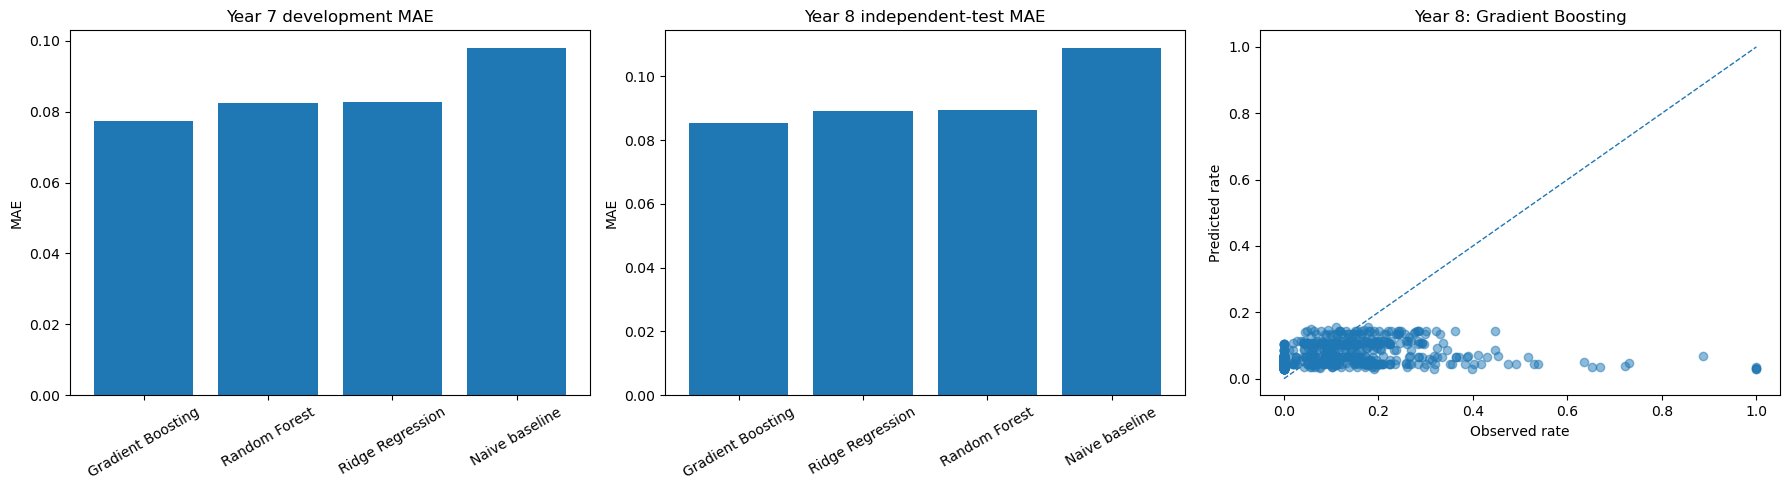

Saved figure: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/figures/q5_model_comparison.png


In [14]:
validation_plot = (
    common_validation_metrics
    .sort_values("mae")
)

test_plot = (
    common_test_metrics
    .sort_values("mae")
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

axes[0].bar(
    validation_plot["model"],
    validation_plot["mae"],
)

axes[0].set_title(
    "Year 7 development MAE"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("MAE")

axes[0].tick_params(
    axis="x",
    rotation=30,
)

axes[1].bar(
    test_plot["model"],
    test_plot["mae"],
)

axes[1].set_title(
    "Year 8 independent-test MAE"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("MAE")

axes[1].tick_params(
    axis="x",
    rotation=30,
)

axes[2].scatter(
    selected_test_predictions[TARGET],
    selected_test_predictions[
        "predicted_frequent_volunteer_rate"
    ],
    alpha=0.5,
)

plot_min = min(
    selected_test_predictions[
        TARGET
    ].min(),
    selected_test_predictions[
        "predicted_frequent_volunteer_rate"
    ].min(),
)

plot_max = max(
    selected_test_predictions[
        TARGET
    ].max(),
    selected_test_predictions[
        "predicted_frequent_volunteer_rate"
    ].max(),
)

axes[2].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1,
)

axes[2].set_title(
    f"Year 8: {selected_model}"
)

axes[2].set_xlabel(
    "Observed rate"
)

axes[2].set_ylabel(
    "Predicted rate"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "q5_model_comparison.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

## 14 — Final validation checks

The final checks confirm that:

- model selection used the Year 7 development result;
- validation and test predictions contain the correct years;
- all reported predictions are valid rates;
- no duplicate series–model rows exist in the Year 8 output.

A successful run confirms that the model-selection and independent-test outputs are internally consistent.

In [15]:
if selected_model not in MODEL_NAMES:
    raise ValueError(
        "The selected model is not one of the four approved methods"
    )

if not validation_predictions[
    "year"
].eq(VALIDATION_YEAR).all():
    raise ValueError(
        "Validation predictions contain an unexpected year"
    )

if not test_predictions[
    "year"
].eq(TEST_YEAR).all():
    raise ValueError(
        "Test predictions contain an unexpected year"
    )

for prediction_table in [
    validation_predictions,
    test_predictions,
]:
    if not prediction_table[
        "predicted_frequent_volunteer_rate"
    ].between(0, 1).all():
        raise ValueError(
            "A predicted rate falls outside the interval [0, 1]"
        )

if test_predictions.duplicated(
    subset=[
        "series_id",
        "model",
    ]
).any():
    raise ValueError(
        "Duplicate Year 8 series-model predictions found"
    )

selected_validation_row = (
    common_validation_metrics.loc[
        common_validation_metrics[
            "model"
        ].eq(
            selected_model
        )
    ]
    .iloc[0]
)

selected_test_row = (
    common_test_metrics.loc[
        common_test_metrics[
            "model"
        ].eq(
            selected_model
        )
    ]
    .iloc[0]
)

final_summary = pd.DataFrame(
    {
        "measure": [
            "Selected model",
            "Year 7 validation MAE",
            "Year 8 test MAE",
            "Year 8 skill versus naive",
            "Validation common rows",
            "Test common rows",
        ],
        "value": [
            selected_model,
            selected_validation_row[
                "mae"
            ],
            selected_test_row[
                "mae"
            ],
            selected_test_row[
                "mae_skill_vs_naive"
            ],
            len(validation_common),
            len(test_common),
        ],
    }
)

display(
    final_summary
)

final_summary.to_csv(
    TABLE_DIR
    / "q5_final_model_summary.csv",
    index=False,
)

print(
    "All Q5 model-comparison checks passed."
)

,measure,value
0,Selected model,Gradient Boosting
1,Year 7 validation MAE,0.077379
2,Year 8 test MAE,0.085377
3,Year 8 skill versus naive,0.216164
4,Validation common rows,681
5,Test common rows,685


All Q5 model-comparison checks passed.


## 15 — Save the model-comparison outputs

This module saves the tuning, validation, independent-test and diagnostic results.

A compact JSON summary records the selected model, its parameters and the main model-selection results for reproducibility. Detailed results remain available in the accompanying CSV files.

In [16]:
tuning_table = pd.concat(
    [
        result["tuning_table"]
        for result in tuning_results.values()
    ],
    ignore_index=True,
)

selected_model_parameters = (
    {}
    if selected_model == "Naive baseline"
    else selected_parameters[
        selected_model
    ]
)

selected_fixed_parameters = {}

if selected_model == "Gradient Boosting":
    selected_fixed_parameters = {
        "loss": "huber",
    }
    
model_selection_summary = {
    "target": TARGET,
    "selected_model": str(
        selected_model
    ),
    "tuned_parameters": (
        selected_model_parameters
    ),
    "fixed_parameters": (
        selected_fixed_parameters
    ),
    "numeric_features": (
        NUMERIC_FEATURES
    ),
    "categorical_features": (
        CATEGORICAL_FEATURES
    ),
    "training_years": (
        TRAIN_YEARS
    ),
    "validation_year": (
        VALIDATION_YEAR
    ),
    "test_year": (
        TEST_YEAR
    ),
    "selection_sample": (
        "Observed targets with an "
        "available one-year lag"
    ),
    "primary_selection_metric": (
        "Unweighted MAE"
    ),
    "validation_mae": float(
        selected_validation_row[
            "mae"
        ]
    ),
    "test_mae": float(
        selected_test_row[
            "mae"
        ]
    ),
    "test_skill_vs_naive": float(
        selected_test_row[
            "mae_skill_vs_naive"
        ]
    ),
    "random_state": (
        RANDOM_STATE
    ),
    "prediction_bounds": [
        0.0,
        1.0,
    ],
}

output_tables = {
    "q5_split_overview.csv": (
        split_overview
    ),
    "q5_model_tuning.csv": (
        tuning_table
    ),
    "q5_validation_metrics.csv": (
        validation_metrics
    ),
    "q5_validation_predictions.csv": (
        validation_predictions
    ),
    "q5_test_metrics.csv": (
        test_metrics
    ),
    "q5_test_predictions.csv": (
        test_predictions
    ),
    "q5_selected_model_diagnostics.csv": (
        selected_model_diagnostics
    ),
    "q5_covid_sensitivity.csv": (
        covid_sensitivity
    ),
    "q5_effective_n_sensitivity.csv": (
        effective_n_sensitivity
    ),
    "q5_development_diagnostics.csv": (
        development_diagnostics
    ),
    "q5_development_target_quantiles.csv": (
        target_quantiles
    ),
    "q5_common_validation_comparison.csv": (
        common_validation_metrics.drop(
            columns="complexity_order",
            errors="ignore",
        )
    ),
    "q5_common_test_comparison.csv": (
        common_test_metrics
    ),
}

for filename, dataframe in output_tables.items():
    output_path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved table: "
        f"{output_path}"
    )

summary_path = (
    OUTPUT_DIR
    / "q5_model_selection_summary.json"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_selection_summary,
        file,
        indent=2,
    )

print(
    f"Saved model-selection summary: "
    f"{summary_path}"
)

Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_split_overview.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_model_tuning.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_validation_metrics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_validation_predictions.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_test_metrics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_test_predictions.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_selected_model_diagnostics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_covid_sensitivity.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q5_model_comparison_outputs/tables/q5_effective_n_sensitivity.csv
Saved table: /Users/zsh/Downlo